## Downscaling and moving windows
- Downscaling building volume and tree volume rasters to 30m to have same-level scale with LST images 
- computing moving windows and study the correlations with LST depending on the size of the window.

### Libraries and general paths

In [2]:
!pip install rasterio


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterio.mask import mask
import rasterio
import numpy as np
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling
from scipy.ndimage import uniform_filter
import os

In [4]:
lst_cropped_path = '../../datos-notebooks/0.LST/LST_cropped_celsius.tif'
trees_raster_path = '../../datos-notebooks/2.objects-height/trees_height_0.5m.tif'
build_raster_path = '../../datos-notebooks/2.objects-height/buildings_height_0.5m.tif'

### Downscaling

#### Building area

In [33]:
out_path = '../../datos-notebooks/2.objects-height/buildings_footprint_0.5m.tif'

with rasterio.open(build_raster_path) as src:
    data = src.read(1)
    profile = src.profile

# Create binary raster: 1 = built area, 0 = no building
footprint = np.where(np.isnan(data) | (data <= 0), 0, 1).astype(np.uint8)

# Save raster
profile.update(dtype=rasterio.uint8, count=1, compress='lzw')

with rasterio.open(out_path, 'w', **profile) as dst:
    dst.write(footprint, 1)

print("Saved:", out_path)


Saved: ../../datos-notebooks/2.objects-height/buildings_footprint_0.5m.tif


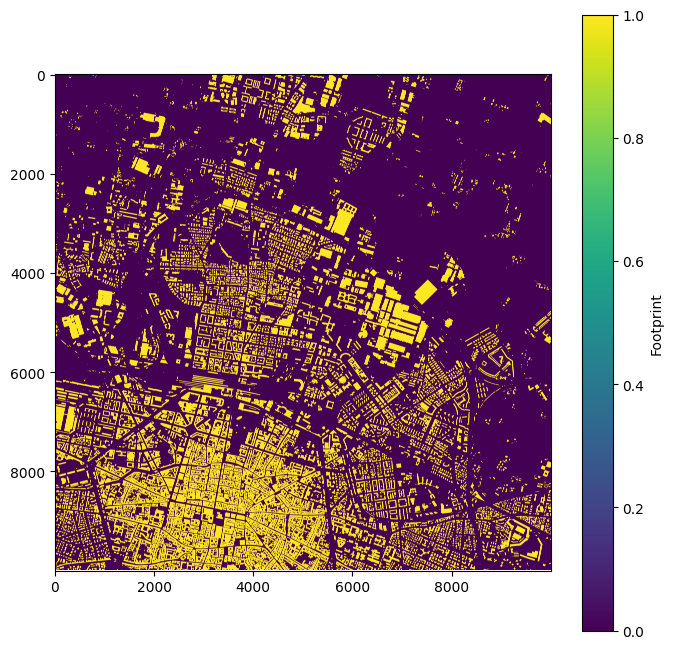

In [34]:
build_footprint_raster_path = '../../datos-notebooks/2.objects-height/buildings_footprint_0.5m.tif'

with rasterio.open(build_footprint_raster_path) as src:
    window = rasterio.windows.Window(col_off=15000, row_off=5000, width=10000, height=10000)  # adjust as needed
    data = src.read(1, window=window)

plt.figure(figsize=(8,8))
plt.imshow(data, cmap='viridis')
plt.colorbar(label='Footprint')
plt.show()

In [38]:
# --- Paths ---
build_footprint_raster_path = '../../datos-notebooks/2.objects-height/buildings_footprint_0.5m.tif'
output_path = '../../datos-notebooks/2.objects-height/buildings_footprint_30m.tif'

# --- Open LST for spatial reference ---
with rasterio.open(lst_cropped_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)
    lst_res = src_lst.res[0]  # pixel size (e.g. 30 m)

# --- Read building footprint raster ---
with rasterio.open(build_footprint_raster_path) as src:
    footprint_data = src.read(1).astype(float)
    footprint_transform = src.transform
    footprint_crs = src.crs
    footprint_res = src.res[0]  # pixel size (e.g. 0.5 m)

# --- Reproject with sum (to count built subpixels per LST pixel) ---
resampled = np.empty(lst_shape, dtype=np.float32)

reproject(
    source=footprint_data,
    destination=resampled,
    src_transform=footprint_transform,
    src_crs=footprint_crs,
    dst_transform=lst_transform,
    dst_crs=lst_crs,
    resampling=Resampling.sum
)

# --- Convert to built fraction ---
scale_factor = (lst_res / footprint_res) ** 2  # number of 0.5m pixels per LST pixel
fraction_built = resampled / scale_factor      # fraction between 0 and 1

# --- Save result ---
out_profile = lst_profile.copy()
out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')

with rasterio.open(output_path, 'w', **out_profile) as dst:
    dst.write(fraction_built, 1)

print("Saved:", output_path)


Saved: ../../datos-notebooks/2.objects-height/buildings_footprint_30m.tif


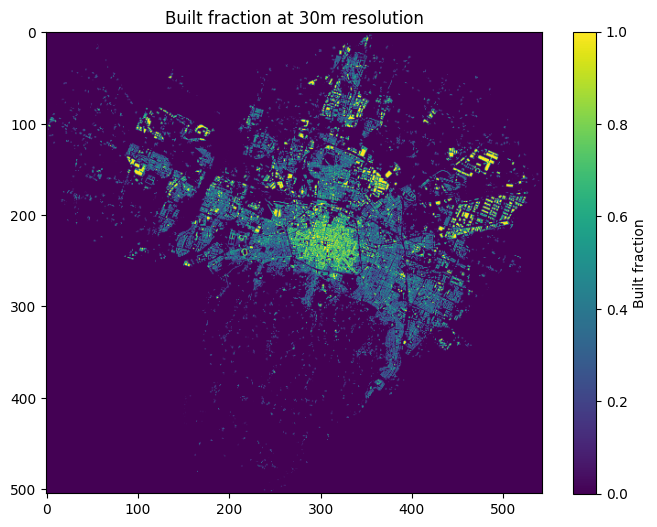

In [40]:
build_footprint = '../../datos-notebooks/2.objects-height/buildings_footprint_30m.tif'
with rasterio.open(build_footprint) as src:
    build_footprint_data = src.read(1)

plt.figure(figsize=(8,6))
plt.imshow(build_footprint_data, cmap='viridis')  # values up to 50.000 but vmax set for better visualization
plt.colorbar(label='Built fraction')
plt.title('Built fraction at 30m resolution')
plt.show()

#### Building volume

In [ ]:
# --- Paths ---
out_path = '../../datos-notebooks/2.objects-height/buildings_volume_30m.tif'

# --- Load LST to get shape, transform, CRS, and pixel size ---
with rasterio.open(lst_cropped_path) as src_lst:
    lst_crs = src_lst.crs
    lst_transform = src_lst.transform
    lst_height = src_lst.height
    lst_width = src_lst.width
    lst_res_x = src_lst.res[0]  # tamaño de pixel LST en X
    lst_res_y = src_lst.res[1]  # tamaño de pixel LST en Y

# --- Load high-res building raster ---
with rasterio.open(build_raster_path) as src_build:
    build_data = src_build.read(1)
    build_res = src_build.res[0]  # asumimos cuadrado 0.5m
    build_transform = src_build.transform

# --- Factor de agregación ---
factor_x = int(lst_res_x / build_res)
factor_y = int(lst_res_y / build_res)

# --- Inicializar raster de volumen ---
volume_raster = np.zeros((lst_height, lst_width), dtype=np.float32)
pixel_area = build_res * build_res  # área de cada pixel 0.5 m

# --- Downscaling sumando volúmenes ---
for i in range(lst_height):
    for j in range(lst_width):
        # calcular ventana de pixels en build_data que caen dentro del pixel LST
        row_start = i * factor_y
        row_end = min((i+1) * factor_y, build_data.shape[0])
        col_start = j * factor_x
        col_end = min((j+1) * factor_x, build_data.shape[1])

        # extraer bloque y calcular volumen
        block = build_data[row_start:row_end, col_start:col_end]
        block = np.nan_to_num(block)  # convertir NaN a 0
        volume_raster[i, j] = np.sum(block * pixel_area)

# --- Guardar raster ---
with rasterio.open(
    out_path,
    'w',
    driver='GTiff',
    height=lst_height,
    width=lst_width,
    count=1,
    dtype=volume_raster.dtype,
    crs=lst_crs,
    transform=lst_transform
) as dst:
    dst.write(volume_raster, 1)


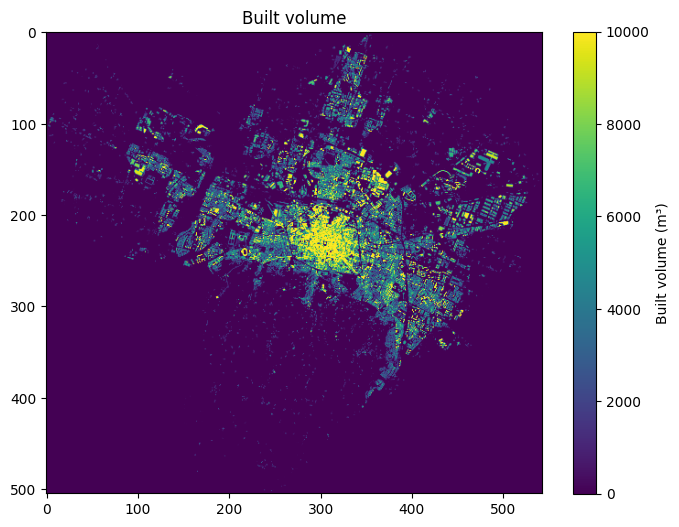

In [35]:
plt.figure(figsize=(8,6))
plt.imshow(volume_raster, cmap='viridis', vmin=0, vmax=10000)  # values up to 50.000 but vmax set for better visualization
plt.colorbar(label='Built volume (m³)')
plt.title('Built volume')
plt.show()

#### Trees volume

In [7]:
# --- Paths ---
out_path = '../../datos-notebooks/2.objects-height/trees_volume_30m.tif'

# --- Load LST to get shape, transform, CRS, and pixel size ---
with rasterio.open(lst_cropped_path) as src_lst:
    lst_crs = src_lst.crs
    lst_transform = src_lst.transform
    lst_height = src_lst.height
    lst_width = src_lst.width
    lst_res_x = src_lst.res[0]  # tamaño de pixel LST en X
    lst_res_y = src_lst.res[1]  # tamaño de pixel LST en Y

# --- Load high-res building raster ---
with rasterio.open(trees_raster_path) as src_tree:
    build_data = src_tree.read(1)
    build_res = src_tree.res[0]  # asumimos cuadrado 0.5m
    build_transform = src_tree.transform

# --- Factor de agregación ---
factor_x = int(lst_res_x / build_res)
factor_y = int(lst_res_y / build_res)

# --- Inicializar raster de volumen ---
volume_raster = np.zeros((lst_height, lst_width), dtype=np.float32)
pixel_area = build_res * build_res  # área de cada pixel 0.5 m

# --- Downscaling sumando volúmenes ---
for i in range(lst_height):
    for j in range(lst_width):
        # calcular ventana de pixels en build_data que caen dentro del pixel LST
        row_start = i * factor_y
        row_end = min((i+1) * factor_y, build_data.shape[0])
        col_start = j * factor_x
        col_end = min((j+1) * factor_x, build_data.shape[1])

        # extraer bloque y calcular volumen
        block = build_data[row_start:row_end, col_start:col_end]
        block = np.nan_to_num(block)  # convertir NaN a 0
        volume_raster[i, j] = np.sum(block * pixel_area)

# --- Guardar raster ---
with rasterio.open(
    out_path,
    'w',
    driver='GTiff',
    height=lst_height,
    width=lst_width,
    count=1,
    dtype=volume_raster.dtype,
    crs=lst_crs,
    transform=lst_transform
) as dst:
    dst.write(volume_raster, 1)

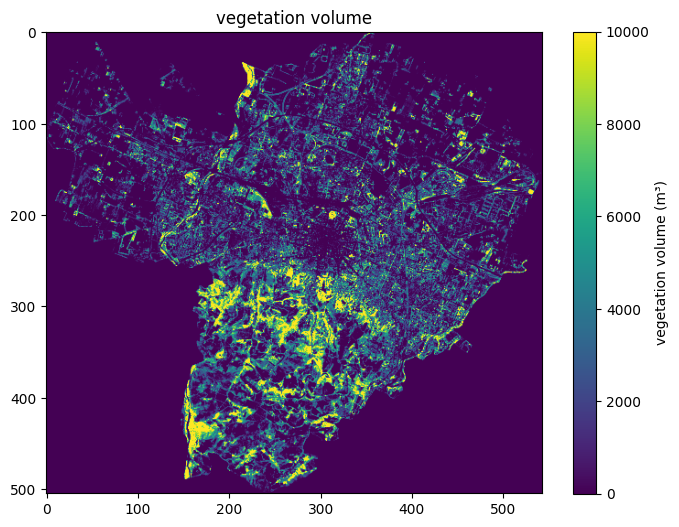

In [8]:
plt.figure(figsize=(8,6))
plt.imshow(volume_raster, cmap='viridis', vmin=0, vmax=10000)  # values up to 50.000 but vmax set for better visualization
plt.colorbar(label='vegetation volume (m³)')
plt.title('vegetation volume')
plt.show()

### moving windows (1 to 20 for each class)

#### Building area

In [41]:
build_footprint_30m = '../../datos-notebooks/2.objects-height/buildings_footprint_30m.tif'

output_folder = "building_area_pct_30m_moving_window/"
os.makedirs(output_folder, exist_ok=True)

with rasterio.open(build_footprint_30m) as src:
    data = src.read(1)
    profile = src.profile

    # Loop over window sizes
    for window_size in range(1, 21):  
        # Apply moving window (convolve computes the sum)
        from scipy.ndimage import convolve

        smoothed = convolve(data, np.ones((window_size, window_size)), mode='nearest')

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(output_folder, f"building_area_window{window_size}.tif")

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)

        print(f"Saved {out_path}")

Saved building_area_pct_30m_moving_window/building_area_window1.tif
Saved building_area_pct_30m_moving_window/building_area_window2.tif
Saved building_area_pct_30m_moving_window/building_area_window3.tif
Saved building_area_pct_30m_moving_window/building_area_window4.tif
Saved building_area_pct_30m_moving_window/building_area_window5.tif
Saved building_area_pct_30m_moving_window/building_area_window6.tif
Saved building_area_pct_30m_moving_window/building_area_window7.tif
Saved building_area_pct_30m_moving_window/building_area_window8.tif
Saved building_area_pct_30m_moving_window/building_area_window9.tif
Saved building_area_pct_30m_moving_window/building_area_window10.tif
Saved building_area_pct_30m_moving_window/building_area_window11.tif
Saved building_area_pct_30m_moving_window/building_area_window12.tif
Saved building_area_pct_30m_moving_window/building_area_window13.tif
Saved building_area_pct_30m_moving_window/building_area_window14.tif
Saved building_area_pct_30m_moving_window/b

#### Building volume

In [ ]:
build_30m = '../../datos-notebooks/2.objects-height/buildings_volume_30m.tif'

output_folder = "buildings_pct_30m_moving_window/"
os.makedirs(output_folder, exist_ok=True)

with rasterio.open(build_30m) as src:
    data = src.read(1)
    profile = src.profile

    # Loop over window sizes
    for window_size in range(1, 21):  
        # Apply moving window (convolve computes the sum)
        from scipy.ndimage import convolve

        smoothed = convolve(data, np.ones((window_size, window_size)), mode='nearest')

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(output_folder, f"buildings_window{window_size}.tif")

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)

        print(f"Saved {out_path}")

Saved buildings_pct_30m_moving_window/buildings_window1.tif
Saved buildings_pct_30m_moving_window/buildings_window2.tif
Saved buildings_pct_30m_moving_window/buildings_window3.tif
Saved buildings_pct_30m_moving_window/buildings_window4.tif
Saved buildings_pct_30m_moving_window/buildings_window5.tif
Saved buildings_pct_30m_moving_window/buildings_window6.tif
Saved buildings_pct_30m_moving_window/buildings_window7.tif
Saved buildings_pct_30m_moving_window/buildings_window8.tif
Saved buildings_pct_30m_moving_window/buildings_window9.tif
Saved buildings_pct_30m_moving_window/buildings_window10.tif
Saved buildings_pct_30m_moving_window/buildings_window11.tif
Saved buildings_pct_30m_moving_window/buildings_window12.tif
Saved buildings_pct_30m_moving_window/buildings_window13.tif
Saved buildings_pct_30m_moving_window/buildings_window14.tif
Saved buildings_pct_30m_moving_window/buildings_window15.tif
Saved buildings_pct_30m_moving_window/buildings_window16.tif
Saved buildings_pct_30m_moving_wi

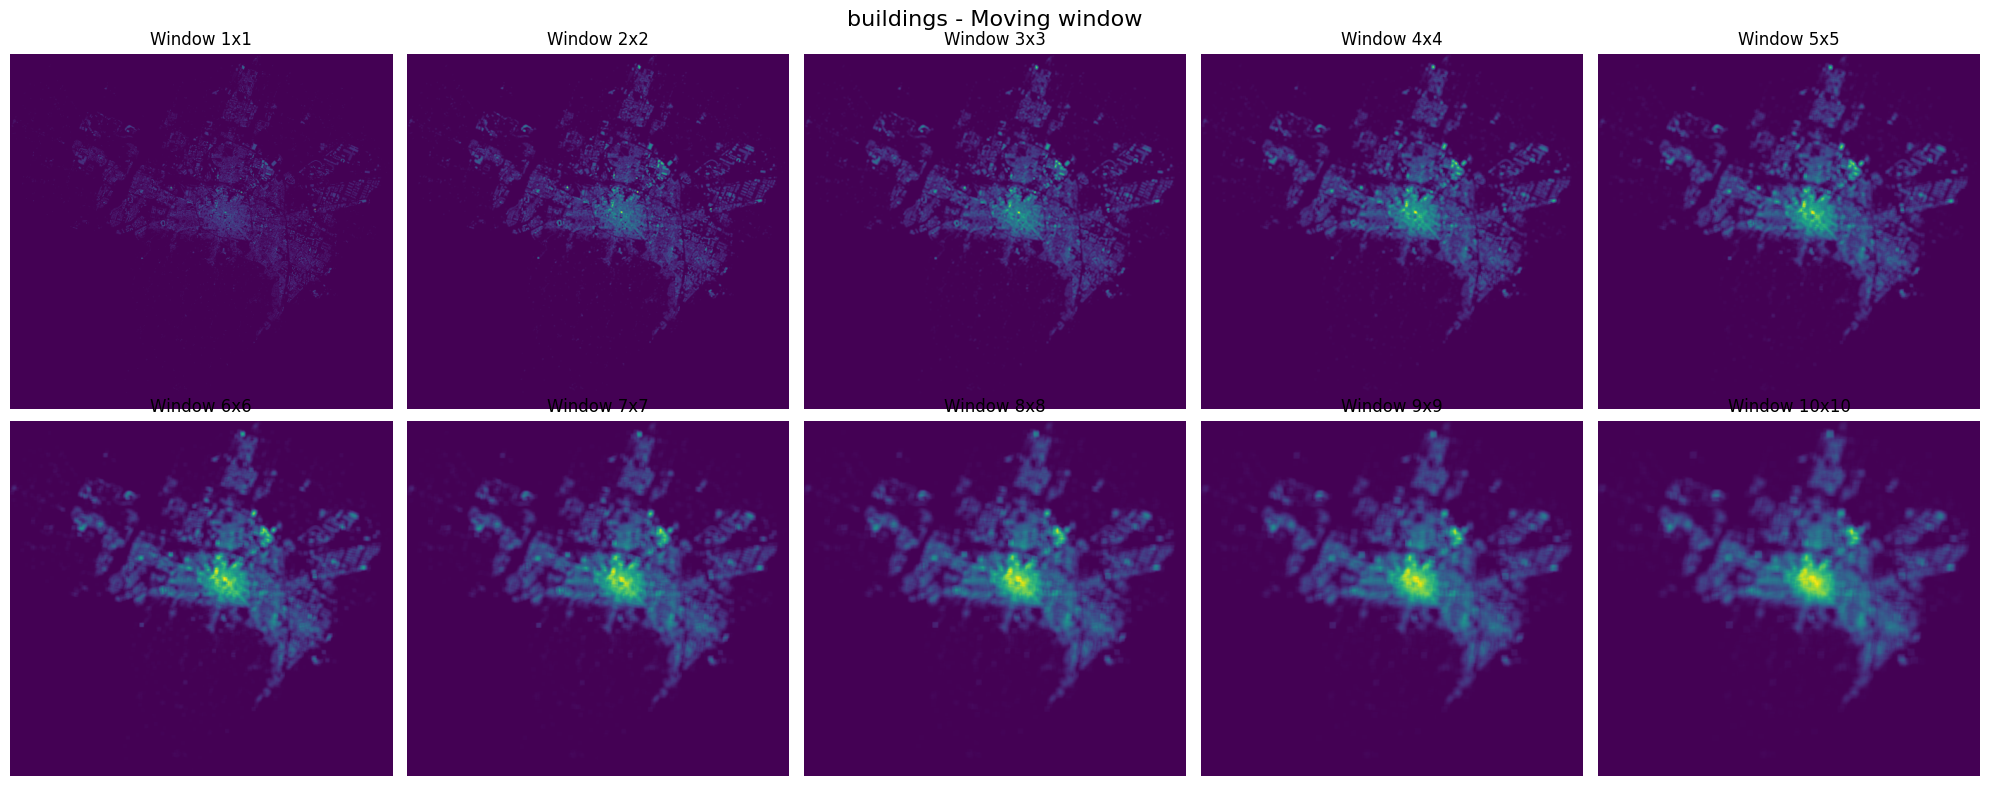

In [25]:
output_folder = "buildings_pct_30m_moving_window/"

fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 2 rows x 5 columns = 10 windows
axes = axes.flatten()

for window_size in range(1, 11):
    raster_path = os.path.join(output_folder, f"buildings_window{window_size}.tif")
    with rasterio.open(raster_path) as src:
        data = src.read(1)  # read first band directly

    ax = axes[window_size-1]
    im = ax.imshow(data, cmap='viridis')
    ax.set_title(f"Window {window_size}x{window_size}")
    ax.axis("off")

fig.suptitle("buildings - Moving window", fontsize=16)
plt.tight_layout()
plt.show()


#### Tree volume

In [19]:
trees_30m = '../../datos-notebooks/2.objects-height/trees_volume_30m.tif'

output_folder = "trees_pct_30m_moving_window/"
os.makedirs(output_folder, exist_ok=True)

with rasterio.open(trees_30m) as src:
    data = src.read(1)
    profile = src.profile

    # Loop over window sizes
    for window_size in range(1, 21):  
        # Apply moving window (convolve computes the sum)
        from scipy.ndimage import convolve

        smoothed = convolve(data, np.ones((window_size, window_size)), mode='nearest')

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(output_folder, f"trees_window{window_size}.tif")

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)

        print(f"Saved {out_path}")

Saved trees_pct_30m_moving_window/trees_window1.tif
Saved trees_pct_30m_moving_window/trees_window2.tif
Saved trees_pct_30m_moving_window/trees_window3.tif
Saved trees_pct_30m_moving_window/trees_window4.tif
Saved trees_pct_30m_moving_window/trees_window5.tif
Saved trees_pct_30m_moving_window/trees_window6.tif
Saved trees_pct_30m_moving_window/trees_window7.tif
Saved trees_pct_30m_moving_window/trees_window8.tif
Saved trees_pct_30m_moving_window/trees_window9.tif
Saved trees_pct_30m_moving_window/trees_window10.tif
Saved trees_pct_30m_moving_window/trees_window11.tif
Saved trees_pct_30m_moving_window/trees_window12.tif
Saved trees_pct_30m_moving_window/trees_window13.tif
Saved trees_pct_30m_moving_window/trees_window14.tif
Saved trees_pct_30m_moving_window/trees_window15.tif
Saved trees_pct_30m_moving_window/trees_window16.tif
Saved trees_pct_30m_moving_window/trees_window17.tif
Saved trees_pct_30m_moving_window/trees_window18.tif
Saved trees_pct_30m_moving_window/trees_window19.tif
Sa

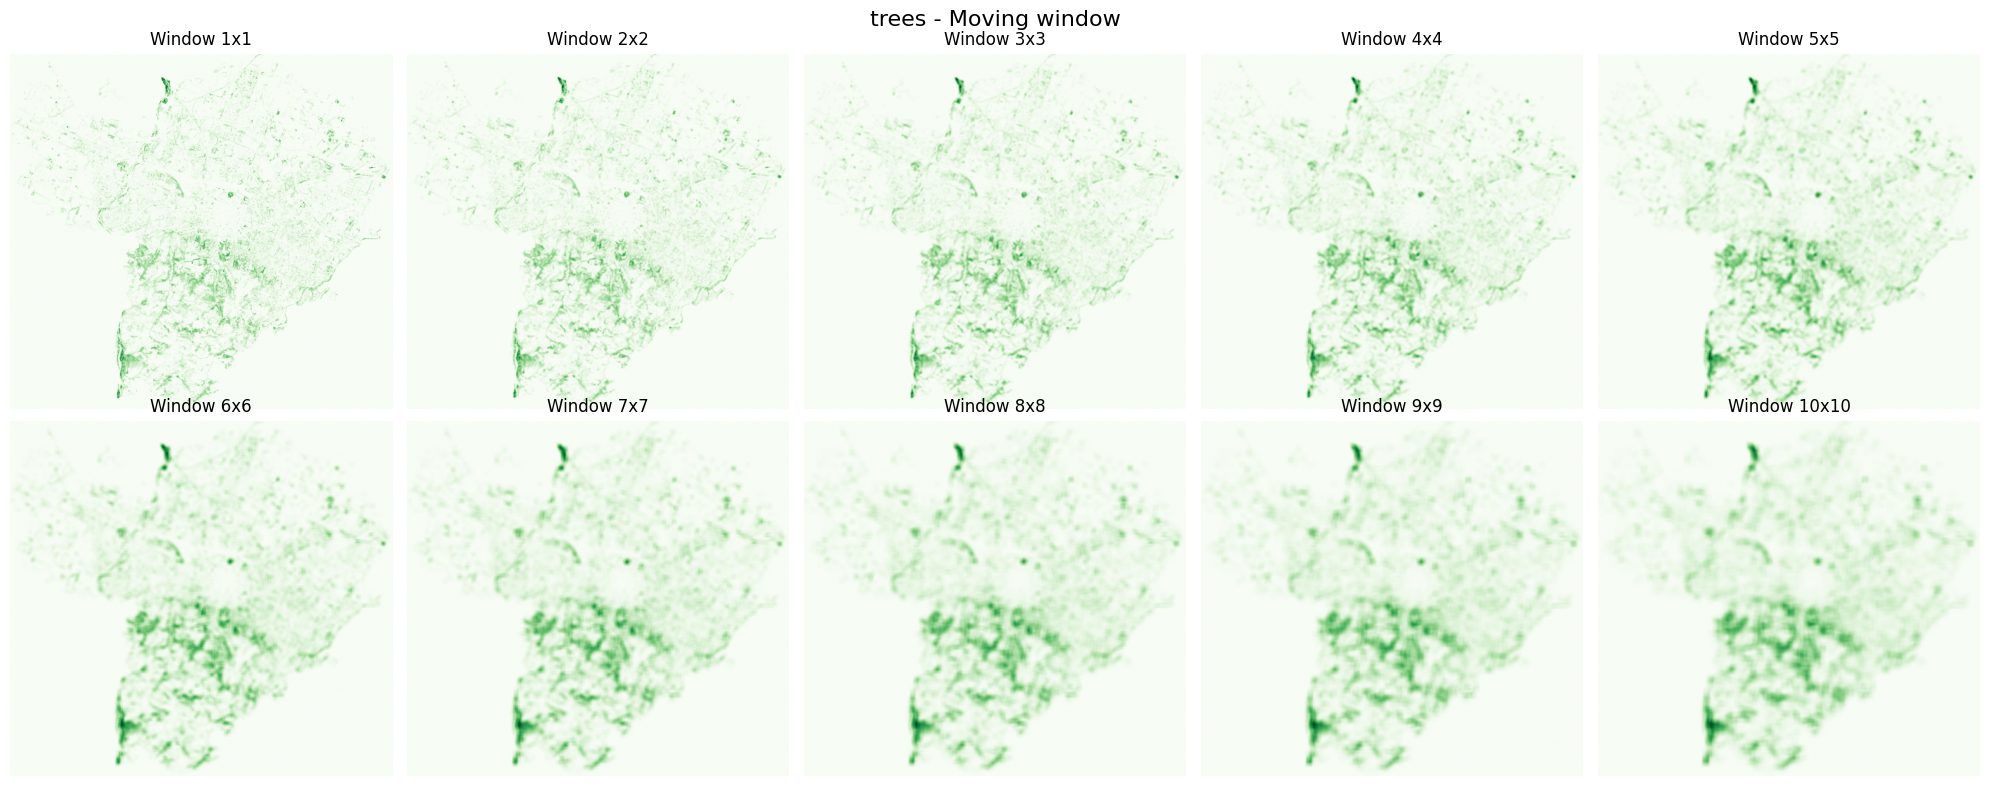

In [27]:
output_folder = "trees_pct_30m_moving_window/"

fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 2 rows x 5 columns = 10 windows
axes = axes.flatten()

for window_size in range(1, 11):
    raster_path = os.path.join(output_folder, f"trees_window{window_size}.tif")
    with rasterio.open(raster_path) as src:
        data = src.read(1)  # read first band directly

    ax = axes[window_size-1]
    im = ax.imshow(data, cmap='Greens')
    ax.set_title(f"Window {window_size}x{window_size}")
    ax.axis("off")

fig.suptitle("trees - Moving window", fontsize=16)
plt.tight_layout()
plt.show()


### Correlations with LST

In [5]:
# --- Paths ---
lst_cropped_path = '../../datos-notebooks/0.LST/LST_cropped_celsius.tif'

# --- general parameters ---
window_sizes = range(1, 21)

# --- Load LST ---
with rasterio.open(lst_cropped_path) as lst:
    lst_crs = lst.crs
    lst_crop = lst.read(1)          
    lst_transform = lst.transform  

#### Building area

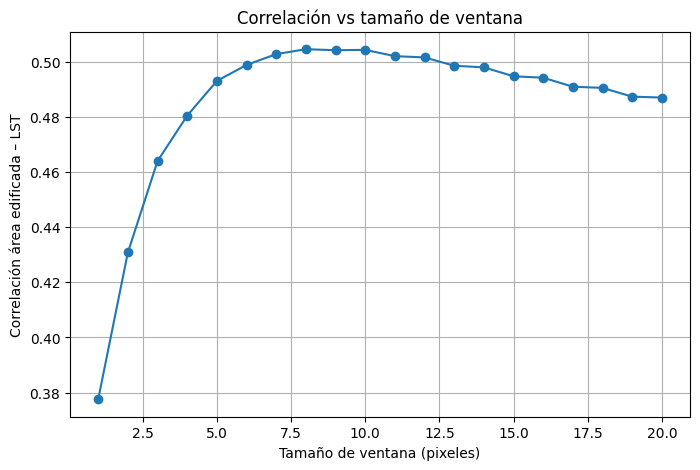

In [8]:
build_area_folder = "building_area_pct_30m_moving_window/"

correlations = []

for w in window_sizes:
    raster_path = os.path.join(build_area_folder, f"building_area_window{w}.tif")
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1).astype(float)  # read full raster

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_crop) & ~np.isnan(raster_data)
    var_vals = raster_data[valid_mask]
    lst_vals = lst_crop[valid_mask]

    corr = np.corrcoef(var_vals, lst_vals)[0,1]
    correlations.append(corr)


# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Tamaño de ventana (pixeles)")
plt.ylabel("Correlación área edificada – LST")
plt.title("Correlación vs tamaño de ventana")
plt.grid(True)
plt.show()

#### Building volume

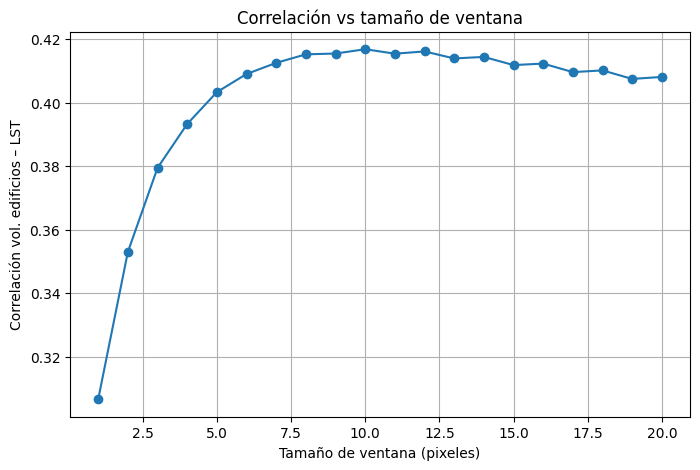

In [9]:
build_folder = "buildings_pct_30m_moving_window/"

correlations = []

for w in window_sizes:
    raster_path = os.path.join(build_folder, f"buildings_window{w}.tif")
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1).astype(float)  # read full raster

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_crop) & ~np.isnan(raster_data)
    var_vals = raster_data[valid_mask]
    lst_vals = lst_crop[valid_mask]

    corr = np.corrcoef(var_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Tamaño de ventana (pixeles)")
plt.ylabel("Correlación vol. edificios – LST")
plt.title("Correlación vs tamaño de ventana")
plt.grid(True)
plt.show()


#### Tree volume

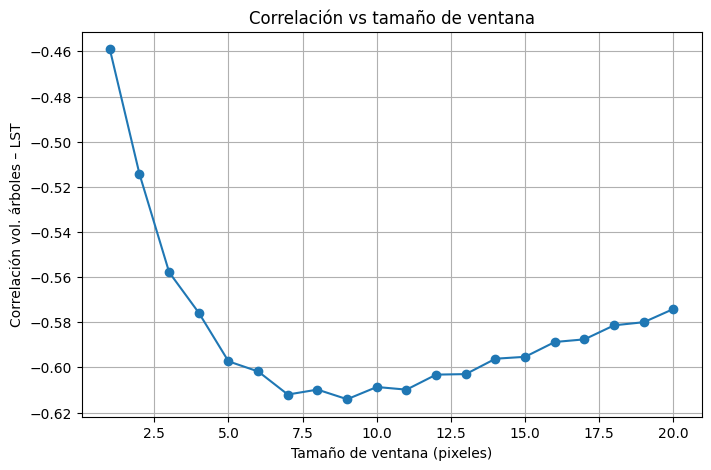

In [10]:
trees_folder = "trees_pct_30m_moving_window/"

correlations = []

for w in window_sizes:
    raster_path = os.path.join(trees_folder, f"trees_window{w}.tif")
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1).astype(float)  # read full raster

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_crop) & ~np.isnan(raster_data)
    var_vals = raster_data[valid_mask]
    lst_vals = lst_crop[valid_mask]

    corr = np.corrcoef(var_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Tamaño de ventana (pixeles)")
plt.ylabel("Correlación vol. árboles – LST")
plt.title("Correlación vs tamaño de ventana")
plt.grid(True)
plt.show()
